First pass at making a baseline generator (spend, channel, impressions)

Based on the marketing funnel, we can create the following casual diagram:

Spend -> Impressions -> (Conversions) -> Revenue 

* Conversions represents those who see the ad and proceed to purchase the product. 

Since this is relatively basic we will assume that: 

- Spend is randomized since we do not have a specific business we are modeling
- Impressions are a transformation of the spend with some noise
- Revenue consists of baseline demand + incremental media channel effect + noise

Assumptions: 
- Values are always positive
- Week-to-week values can jump a lot (we can add smoothness later)
- For now this means weeks are independent of each other 

Let’s say we want to model an ROI of 2. Based off of the monthly_mocha sample dataset  I created some range estimates keeping the ROI in mind:

Spend (10,000 - 100,000) 
Impressions (100,000 - 1,000,000)
Revenue (20,000 - 200,000)

Noise terms are iid normal with zero mean and standard deviation equal to 5% the expected value of the corresponding range. (*Note: the standard deviation was an arbitrary choice)

Calculations for each week: 
* weekly_spend : random value from the given range
* weekly_impressions : weekly_spend * channel_efficiency + noise 
* weekly_revenue:  baseline_revenue +  (weekly_impressions * channel_conversions) *  revenue_per_conversion + noise

- Channel_efficiency refers to the impressions per dollar spent
- Baseline_revenue refers to the demand without any marketing intervention (arbitrary choice) 
- Channel_conversions refers to how many people make it down the marketing funnel and purchase the - product (arbitrary choice)
- Revenue_per_conversion refers to the price of the product 


In [2]:
# Spend (10,000 - 100,000)
# Impressions (100,000 - 1,000,000)
# Revenue (20,000 - 200,000)

import numpy as np
import random
import pandas as pd
random.seed(99)

spend = []
impressions = []
revenue = []

#impressions per dollar spend
channel_efficieny = 10

# 10% of users see the ad -> and buy
channel_conversions = 0.1
revenue_per_conversion = 2
baseline_revenue = 20000

noise = 0

weeks = 52
for i in range (1,weeks+1):
    weekly_spend = random.randrange(10000, 100000)
    spend.append(weekly_spend)
    weekly_impressions = weekly_spend * channel_efficieny + np.random.normal(loc=0, scale=25000)
    impressions.append(weekly_impressions)
    weekly_revenue = baseline_revenue + (weekly_impressions * channel_conversions) * revenue_per_conversion + np.random.normal(loc=0, scale=5500)
    revenue.append(weekly_revenue)

df = pd.DataFrame(data = {'Spend':spend, 'Impressions':impressions, 'Revenue':revenue})
df

,Spend,Impressions,Revenue
0,62950,6.145537e+05,147988.039357
1,59906,5.647281e+05,130883.397365
2,36224,3.946445e+05,90247.161879
3,88569,8.548907e+05,189811.810480
4,33435,3.286383e+05,83314.557200
5,40180,4.590406e+05,111032.629463
6,42562,4.529747e+05,109531.613700
7,27464,2.634170e+05,72955.169337
8,21348,1.982336e+05,68213.385347
9,42918,4.466263e+05,106492.238196


In [6]:
#plotting spend values from monthly_mocha.csv
import matplotlib.pyplot as plt

df = pd.read_csv("../data/monthly_mocha.csv")
df.head()

,date,subscriptions,meta_spend,meta_impressions,google_spend,google_impressions,snapchat_spend,snapchat_impressions,tiktok_spend,tiktok_impressions,moloco_spend,moloco_impressions,liveintent_spend,liveintent_impressions,roku_spend,roku_impressions,beehiiv_spend,beehiiv_impressions,amazon_spend,amazon_impressions
0,8/4/25,15540,91538.06648,16572258,116667.9945,6473132,94750.04035,3420454,0.0,0,6564.524233,367206,37766.44904,371854,0,0,18190.10332,181901,0.0,0
1,7/28/25,14525,93840.18612,25300600,180486.9558,9487127,99447.23218,3235285,0.0,0,18111.083980,820589,38543.27888,347850,0,0,20063.91811,200639,0.0,0
2,7/21/25,16880,48403.06780,14099214,200817.3250,7909118,84738.57435,4766750,0.0,0,9714.794608,369806,39697.42202,322865,0,0,20828.00074,208280,0.0,0
3,7/14/25,20113,49470.96783,13652072,215770.9242,7789279,83204.40500,4022680,0.0,0,16831.841440,554980,40561.34006,570418,0,0,24097.34426,240973,0.0,0
4,7/7/25,16492,48948.28744,10121002,209231.9668,6806878,82642.37271,4532105,0.0,0,17624.908800,894891,40012.42040,483619,0,0,19967.60420,199676,0.0,0


<Axes: >

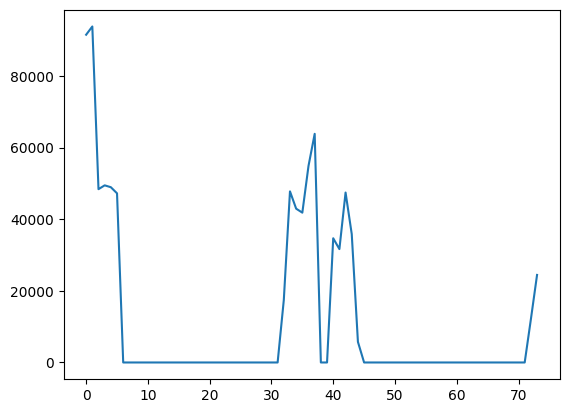

In [ ]:
#plotting spend
df.plot.scatter(x=?, y="meta_spend", alpha=0.5)



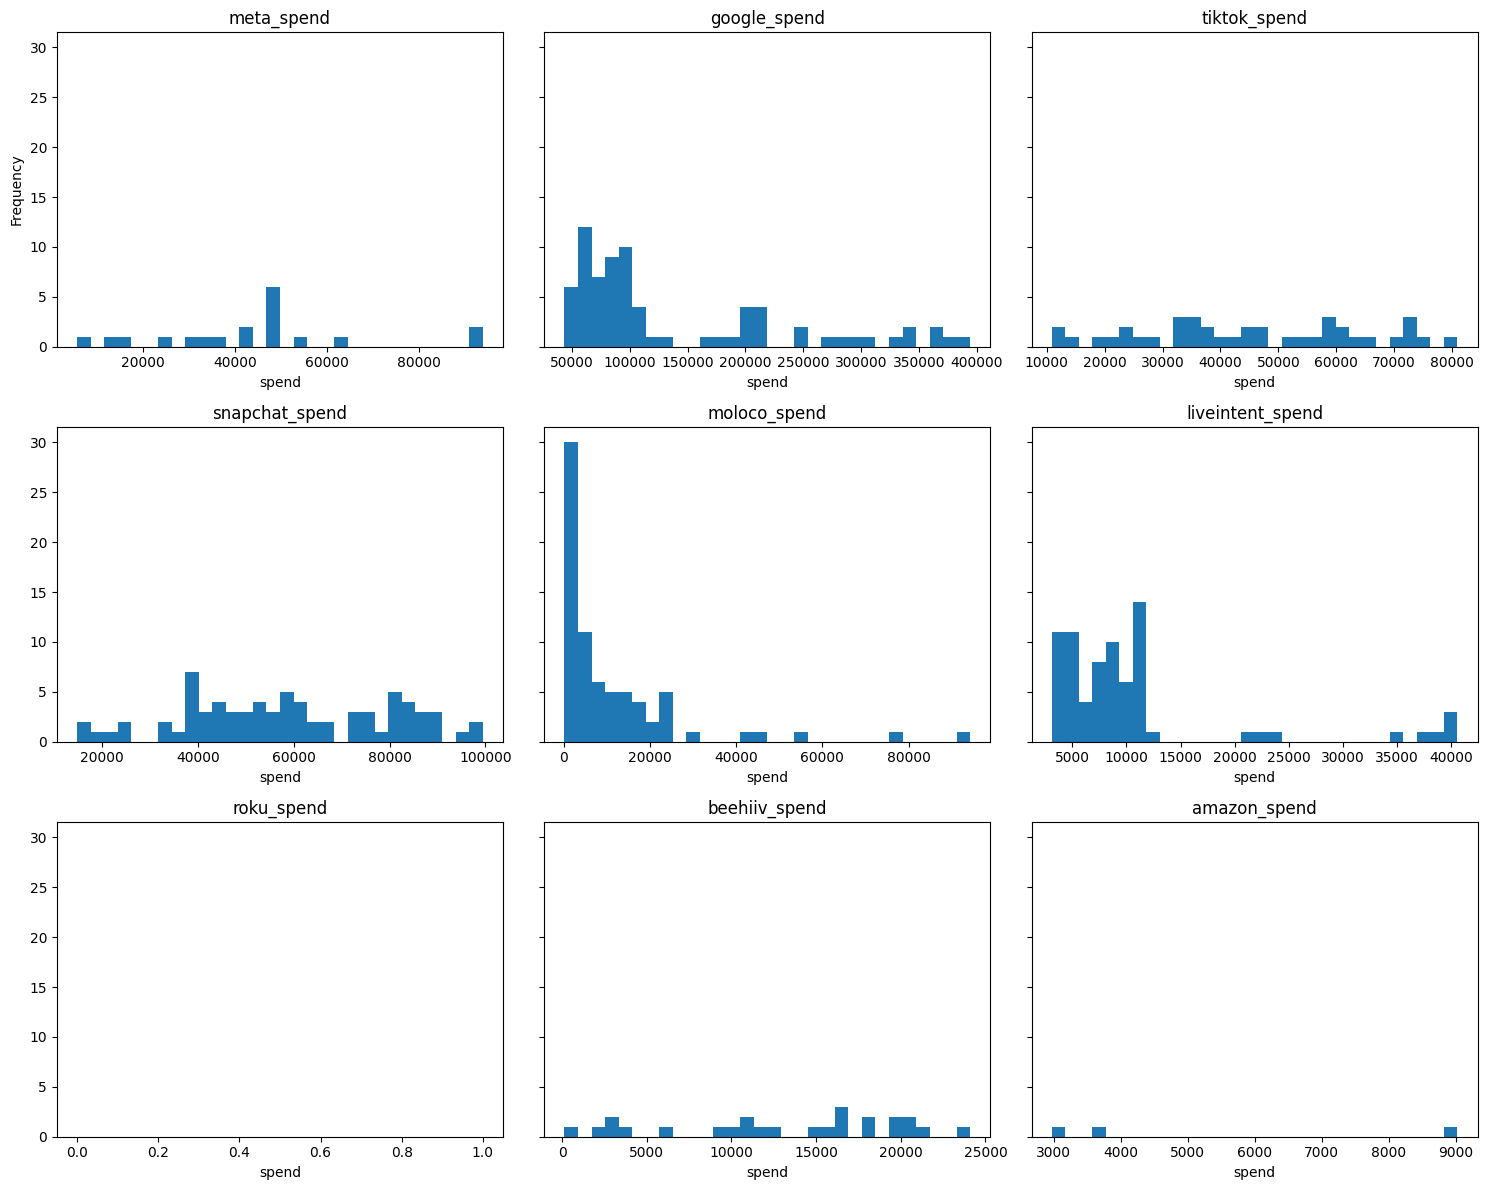

In [18]:
import numpy as np
import matplotlib.pyplot as plt

cols = [
    'meta_spend', 'google_spend', 'tiktok_spend',
    'snapchat_spend', 'moloco_spend', 'liveintent_spend',
    'roku_spend', 'beehiiv_spend', 'amazon_spend'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=True)
axes = axes.flatten() 

for ax, col in zip(axes, cols):
    data = df.loc[df[col] > 0, col]   # exclude zeros
    ax.hist(data, bins=30)
    ax.set_title(col)
    ax.set_xlabel('spend')

axes[0].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [20]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# columns
x_col = 'meta_spend'
y_col = 'meta_impressions'

# drop missing / zero values (adjust as needed)
df_reg = df[[x_col, y_col]].dropna()
df_reg = df_reg[df_reg[x_col] > 0]

X = sm.add_constant(df_reg[x_col])  # adds intercept
y = df_reg[y_col]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       meta_impressions   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     72.85
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.49e-07
Time:                        16:29:37   Log-Likelihood:                -305.00
No. Observations:                  19   AIC:                             614.0
Df Residuals:                      17   BIC:                             615.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.342e+05   1.23e+06      0.596      0.5

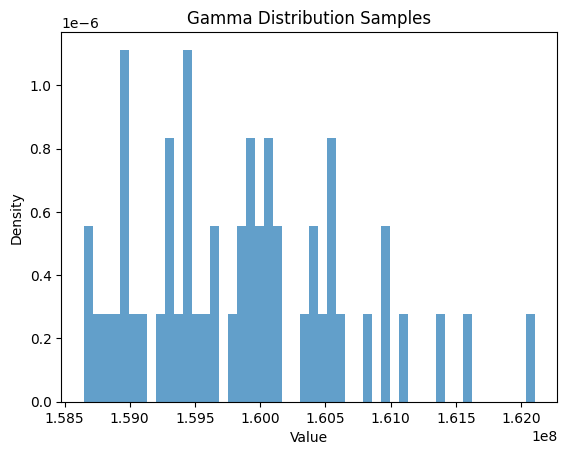

In [44]:
import numpy as np
import matplotlib.pyplot as plt


n = 52        # number of samples
shape = 40000   # k (α)
rate = 7   # θ

weekly_spend = np.random.gamma(shape=shape, scale=scale, size=n)

plt.hist(weekly_spend, bins=50, density=True, alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Gamma Distribution Samples')
plt.show()

In [45]:
weekly_spend = weekly_spend.tolist()
weekly_spend

[160128350.17597768,
 158945562.04115754,
 161117363.71634486,
 159436611.91167736,
 159064916.62076873,
 160518143.87456512,
 160647187.57445642,
 159954109.02630866,
 160398741.3770998,
 159001494.53909585,
 160123634.15923494,
 158983147.41245443,
 160850233.7416674,
 160089030.40789467,
 159914145.4056669,
 160933258.37295738,
 159626250.82000715,
 159276620.70205525,
 158860060.64791822,
 159883655.36609596,
 160017881.13442373,
 161345574.68355295,
 159506800.2656368,
 158809635.21297735,
 159635615.50467917,
 159473140.32307532,
 160050147.15373415,
 162103884.05721647,
 158768270.21747515,
 160095979.15967253,
 159425941.32893476,
 159367921.82897,
 159293552.31637397,
 159298863.27405953,
 160528500.55712953,
 158699011.56055576,
 160372919.43552372,
 159970788.85267815,
 161573759.15153795,
 159552253.59667498,
 159868590.36959907,
 159898971.34575936,
 159788179.13431612,
 160974770.51493943,
 158949334.27950808,
 159416392.62506697,
 158648034.6785364,
 159254150.65638036,


In [46]:
#based on regression coeffcients

params = model.params
print(params)

weekly_impressions

const         734186.621962
meta_spend       212.659990
dtype: float64


[np.float64(170301843444.61844),
 np.float64(170434506305.07437),
 np.float64(170509330561.05963),
 np.float64(170663835752.119),
 np.float64(170429286733.47714),
 np.float64(170160122738.72586),
 np.float64(169858579254.42358),
 np.float64(170062277436.80054),
 np.float64(170242847687.77695),
 np.float64(169836095829.46164),
 np.float64(170102036560.98367),
 np.float64(170332878048.11975),
 np.float64(170452895025.97778),
 np.float64(170389703986.72614),
 np.float64(169301359938.40207),
 np.float64(169657157750.0116),
 np.float64(170122007376.7592),
 np.float64(170221705374.8847),
 np.float64(170043253274.20743),
 np.float64(170267091846.91534),
 np.float64(170511243396.4594),
 np.float64(169794655613.3125),
 np.float64(170645678002.03766),
 np.float64(169538355159.53308),
 np.float64(170395399220.84518),
 np.float64(170029085041.82),
 np.float64(170284113497.29468),
 np.float64(169978297995.62396),
 np.float64(169947105612.7367),
 np.float64(170437872087.64578),
 np.float64(170213249

In [47]:
params['meta_spend']

np.float64(212.65999047387618)

In [48]:
weekly_impressions = []
for i in weekly_spend: 
    imp = i * params['meta_spend'] + params['const'] + np.random.normal(0,2500)
    weekly_impressions.append(imp)

    
df = pd.DataFrame(data = {'Spend':weekly_spend, 'Impressions':weekly_impressions})  
df  

,Spend,Impressions
0,1.601284e+08,3.405363e+10
1,1.589456e+08,3.380210e+10
2,1.611174e+08,3.426395e+10
3,1.594366e+08,3.390652e+10
4,1.590649e+08,3.382747e+10
5,1.605181e+08,3.413652e+10
6,1.606472e+08,3.416396e+10
7,1.599541e+08,3.401657e+10
8,1.603987e+08,3.411113e+10
9,1.590015e+08,3.381399e+10
